In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

# Real Data
### https://www.kaggle.com/c/house-prices-advanced-regression-techniques?utm_source=gemini

In [14]:
df = pd.read_csv("train.csv", sep = "," , encoding = 'utf-8')
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [15]:
df.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [16]:
df.tail(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1450,1451,90,RL,60.0,9000,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,136000
1451,1452,20,RL,78.0,9262,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2009,New,Partial,287090
1452,1453,180,RM,35.0,3675,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2006,WD,Normal,145000
1453,1454,20,RL,90.0,17217,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2006,WD,Abnorml,84500
1454,1455,20,FV,62.0,7500,Pave,Pave,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,10,2009,WD,Normal,185000
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


# EDA

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [18]:
df.shape

(1460, 81)

In [28]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### Missing Values

In [19]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [30]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

In [20]:
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_data = pd.DataFrame({'Missing Count': missing_values, 'Percentage (%)': missing_percent})
missing_data = missing_data[missing_data['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)
missing_data

,Missing Count,Percentage (%)
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


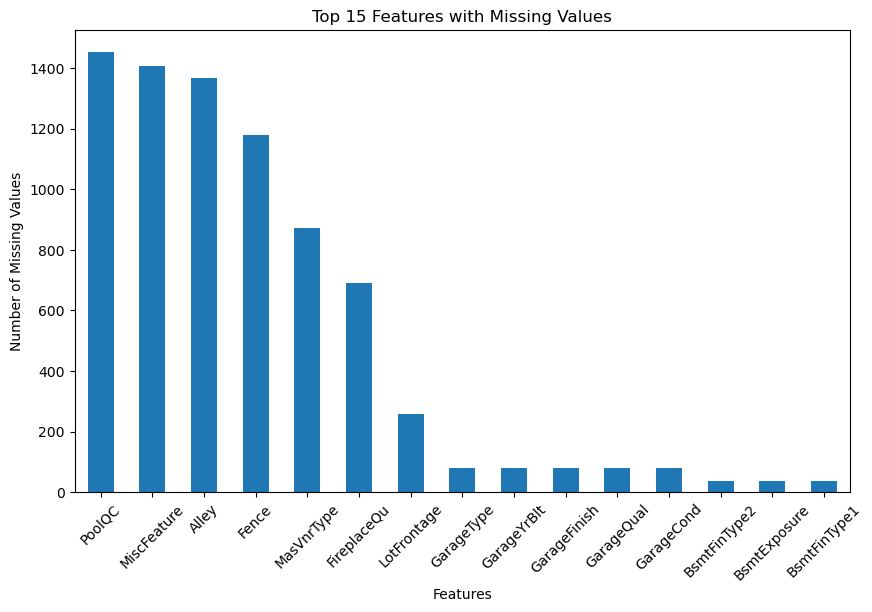

In [31]:
plt.figure(figsize=(10,6))

missing.head(15).plot(kind="bar")

plt.title("Top 15 Features with Missing Values")
plt.xlabel("Features")
plt.ylabel("Number of Missing Values")

plt.xticks(rotation=45)

plt.show()

#### Some features contain many missing values, especially features related to optional house facilities.

In [22]:
df.duplicated().sum()

np.int64(0)

In [32]:
categorical_cols = df.select_dtypes(include="object").columns
len(categorical_cols)

43

In [33]:
categorical_cols

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

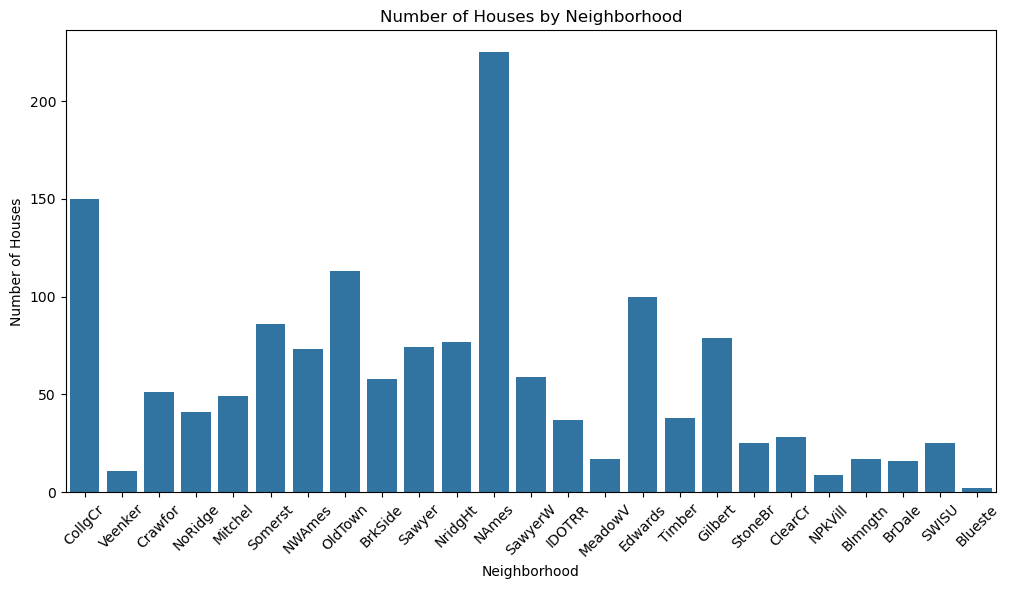

In [35]:
plt.figure(figsize=(12,6))

sns.countplot(data=df, x="Neighborhood")

plt.title("Number of Houses by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Number of Houses")

plt.xticks(rotation=45)

plt.show()

#### The number of houses varies across different neighborhoods.

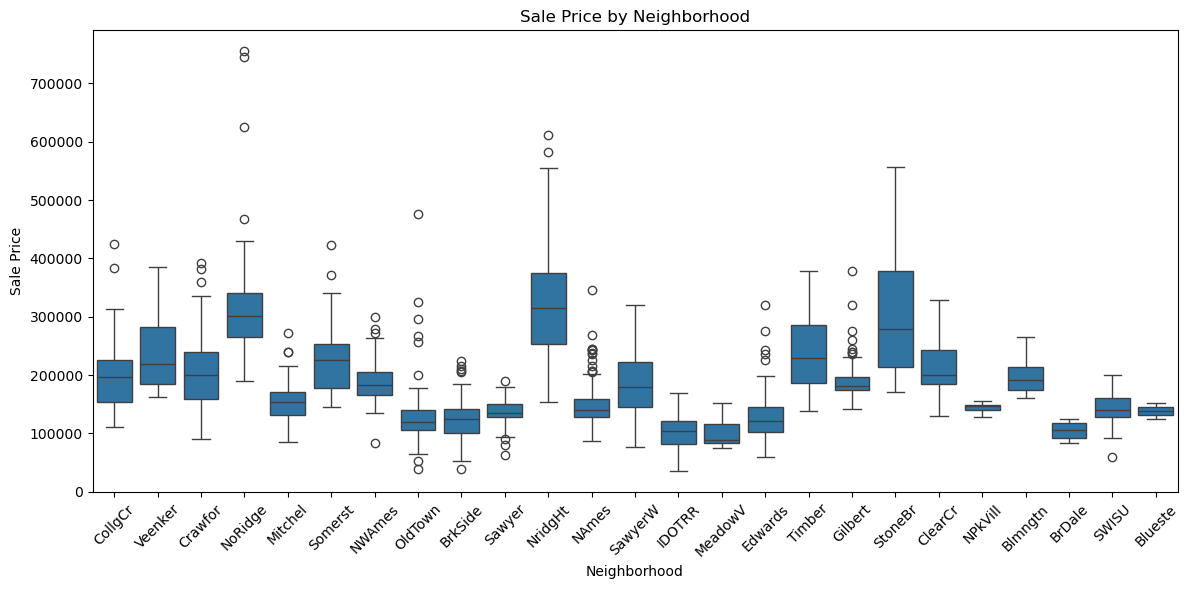

In [38]:
plt.figure(figsize=(14,6))

sns.boxplot(data=df, x="Neighborhood", y="SalePrice")

plt.title("Sale Price by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Sale Price")

plt.xticks(rotation=45)

plt.show()

 #### House prices vary across neighborhoods, showing that location is related to SalePrice.

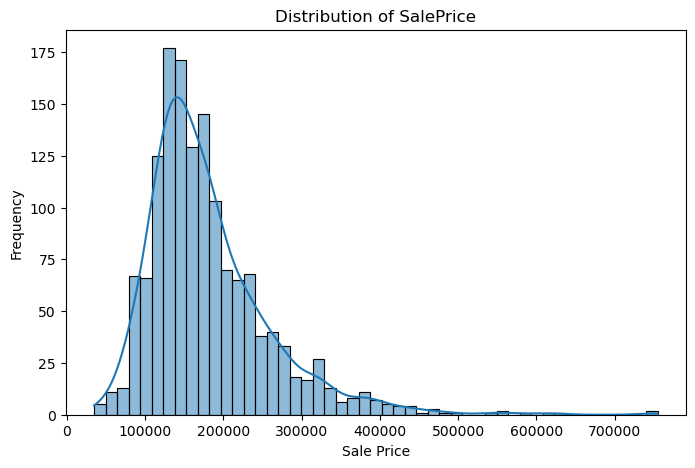

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(df["SalePrice"], kde=True)

plt.title("Distribution of SalePrice")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.show()

#### Most house prices are concentrated in the lower and middle price ranges,
#### with a few houses having very high prices.

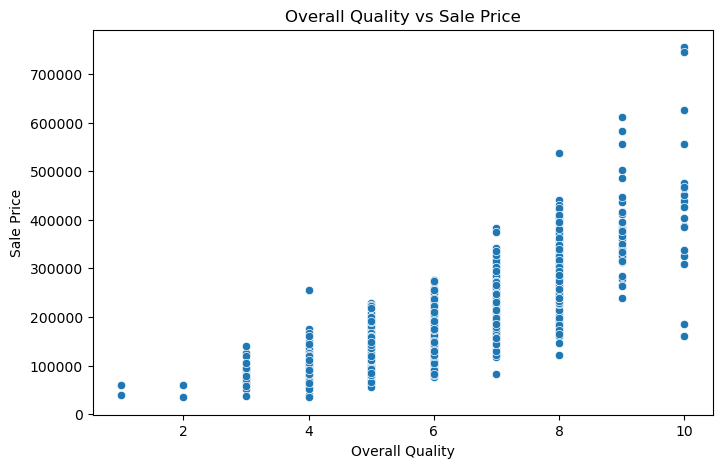

In [40]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="OverallQual", y="SalePrice")

plt.title("Overall Quality vs Sale Price")
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")

plt.show()

#### Higher overall quality is generally associated with higher house prices.

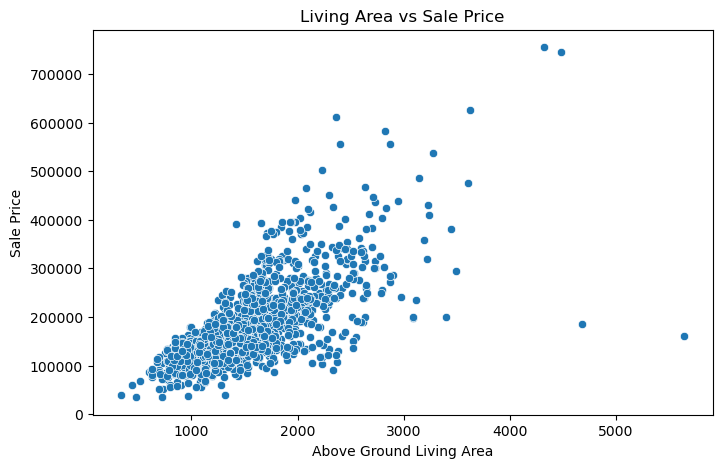

In [41]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="GrLivArea", y="SalePrice")

plt.title("Living Area vs Sale Price")
plt.xlabel("Above Ground Living Area")
plt.ylabel("Sale Price")

plt.show()

#### Larger living areas generally have higher house prices.

In [42]:
corr = df.select_dtypes(include="number").corr()

corr["SalePrice"].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

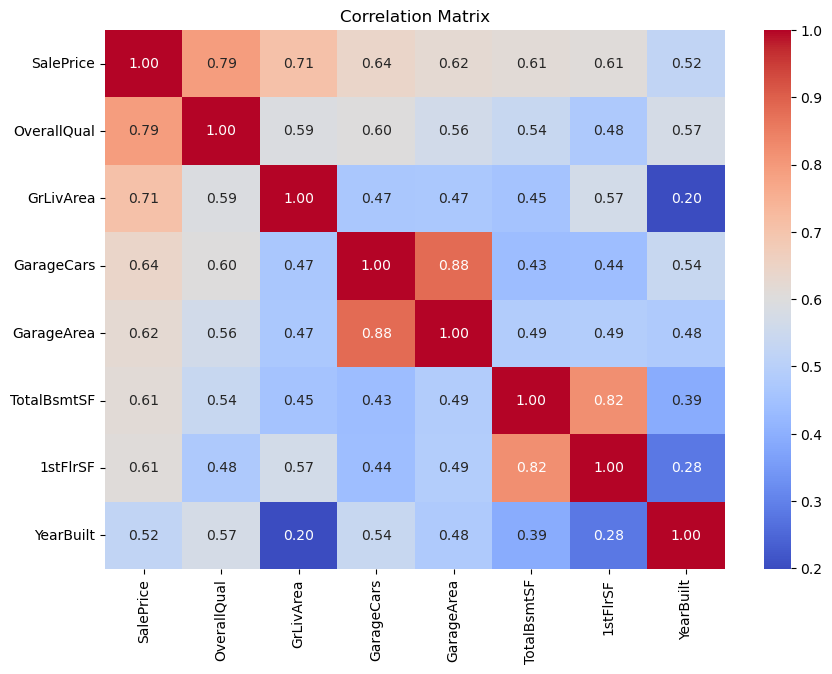

In [43]:
top_features = [
    "SalePrice",
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "YearBuilt"
]

plt.figure(figsize=(10,7))

sns.heatmap(
    df[top_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

#### The heatmap shows the correlations between important numerical features and SalePrice.

### Outliers

In [44]:
numeric_cols = df.select_dtypes(include="number").columns
numeric_cols

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [46]:
outliers = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_count = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()
    
    outliers[col] = outlier_count

In [47]:
outliers_df = pd.DataFrame(
    list(outliers.items()),
    columns=["Feature", "Outlier_Count"]
)

outliers_df = outliers_df.sort_values(
    by="Outlier_Count",
    ascending=False
)

outliers_df

,Feature,Outlier_Count
30,EnclosedPorch,208
10,BsmtFinSF2,167
5,OverallCond,125
32,ScreenPorch,116
1,MSSubClass,103
8,MasVnrArea,96
2,LotFrontage,88
18,BsmtHalfBath,82
29,OpenPorchSF,77
3,LotArea,69


In [48]:
outliers_df[outliers_df["Outlier_Count"] > 0]

,Feature,Outlier_Count
30,EnclosedPorch,208
10,BsmtFinSF2,167
5,OverallCond,125
32,ScreenPorch,116
1,MSSubClass,103
8,MasVnrArea,96
2,LotFrontage,88
18,BsmtHalfBath,82
29,OpenPorchSF,77
3,LotArea,69


In [49]:
outliers_df["Outlier_Percentage"] = (
    outliers_df["Outlier_Count"] / len(df) * 100
)

outliers_df

,Feature,Outlier_Count,Outlier_Percentage
30,EnclosedPorch,208,14.246575
10,BsmtFinSF2,167,11.438356
5,OverallCond,125,8.561644
32,ScreenPorch,116,7.945205
1,MSSubClass,103,7.054795
8,MasVnrArea,96,6.575342
2,LotFrontage,88,6.027397
18,BsmtHalfBath,82,5.616438
29,OpenPorchSF,77,5.273973
3,LotArea,69,4.726027


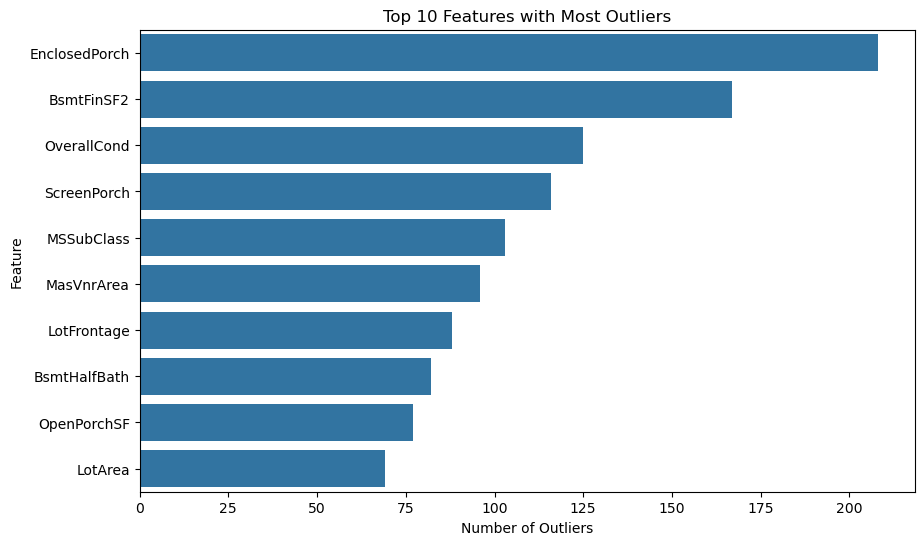

In [50]:
top_outliers = outliers_df.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_outliers,
    x="Outlier_Count",
    y="Feature"
)

plt.title("Top 10 Features with Most Outliers")
plt.xlabel("Number of Outliers")
plt.ylabel("Feature")

plt.show()

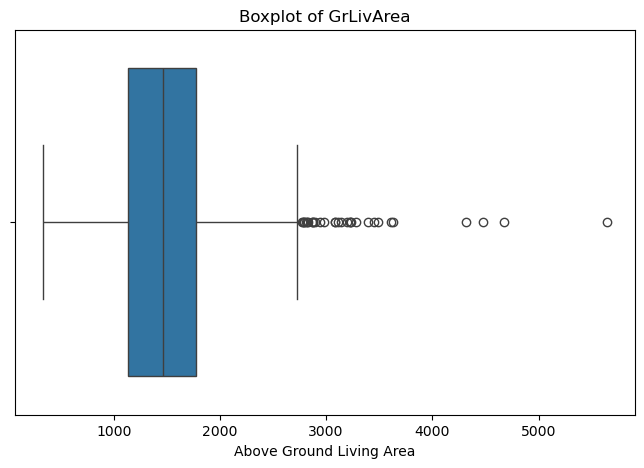

In [51]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["GrLivArea"])

plt.title("Boxplot of GrLivArea")
plt.xlabel("Above Ground Living Area")

plt.show()

#### A few houses have unusually large living areas compared with most houses.

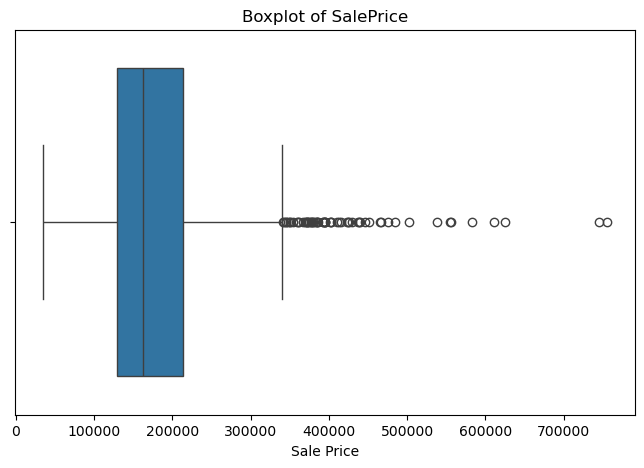

In [52]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["SalePrice"])

plt.title("Boxplot of SalePrice")
plt.xlabel("Sale Price")

plt.show()

## Preprocessing

### Fill Missing data

In [57]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

In [58]:
missing_info = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Data_Type": df.dtypes
})

missing_info = missing_info[missing_info["Missing_Count"] > 0]

missing_info

,Missing_Count,Data_Type
LotFrontage,259,float64
Alley,1369,object
MasVnrType,872,object
MasVnrArea,8,float64
BsmtQual,37,object
BsmtCond,37,object
BsmtExposure,38,object
BsmtFinType1,37,object
BsmtFinType2,38,object
Electrical,1,object


In [59]:
none_cols = [
    "Alley",
    "MasVnrType",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "PoolQC",
    "Fence",
    "MiscFeature"
]

len(none_cols)

15

In [60]:
df[none_cols] = df[none_cols].fillna("None")

In [61]:
df[none_cols].isnull().sum()

Alley           0
MasVnrType      0
BsmtQual        0
BsmtCond        0
BsmtExposure    0
BsmtFinType1    0
BsmtFinType2    0
FireplaceQu     0
GarageType      0
GarageFinish    0
GarageQual      0
GarageCond      0
PoolQC          0
Fence           0
MiscFeature     0
dtype: int64

In [63]:
df["MasVnrArea"].median()

0.0

In [64]:
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)

In [65]:
df["MasVnrArea"].isnull().sum()

np.int64(0)

In [66]:
df[df["GarageYrBlt"].isnull()]["GarageType"].value_counts(dropna=False)

GarageType
None    81
Name: count, dtype: int64

In [67]:
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)

In [68]:
df["GarageYrBlt"].isnull().sum()

np.int64(0)

In [69]:
df["Electrical"].mode()[0]

'SBrkr'

In [70]:
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

In [71]:
df["Electrical"].isnull().sum()

np.int64(0)

In [74]:
df["LotFrontage"].median()

69.0

In [75]:
df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

In [76]:
df["LotFrontage"].isnull().sum()

np.int64(0)

In [77]:
df.isnull().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 81, dtype: int64

## outliers

In [78]:
outliers_df.head(10)

,Feature,Outlier_Count,Outlier_Percentage
30,EnclosedPorch,208,14.246575
10,BsmtFinSF2,167,11.438356
5,OverallCond,125,8.561644
32,ScreenPorch,116,7.945205
1,MSSubClass,103,7.054795
8,MasVnrArea,96,6.575342
2,LotFrontage,88,6.027397
18,BsmtHalfBath,82,5.616438
29,OpenPorchSF,77,5.273973
3,LotArea,69,4.726027


In [79]:
df[["GrLivArea", "SalePrice"]].sort_values(
    by="GrLivArea",
    ascending=False
).head(10)

,GrLivArea,SalePrice
1298,5642,160000
523,4676,184750
1182,4476,745000
691,4316,755000
1169,3627,625000
185,3608,475000
304,3493,295000
1268,3447,381000
635,3395,200000
769,3279,538000


In [80]:
df[df["GrLivArea"] > 4000][
    ["GrLivArea", "SalePrice"]
]

,GrLivArea,SalePrice
523,4676,184750
691,4316,755000
1182,4476,745000
1298,5642,160000


In [81]:
df[
    (df["GrLivArea"] > 4000) &
    (df["SalePrice"] < 300000)
][["Id", "GrLivArea", "SalePrice"]]

,Id,GrLivArea,SalePrice
523,524,4676,184750
1298,1299,5642,160000


In [82]:
df = df.drop(
    df[
        (df["GrLivArea"] > 4000) &
        (df["SalePrice"] < 300000)
    ].index
)

In [83]:
df[
    (df["GrLivArea"] > 4000) &
    (df["SalePrice"] < 300000)
]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


## Feature Engineering

In [128]:
df["TotalSF"] = (
    df["TotalBsmtSF"] +
    df["1stFlrSF"] +
    df["2ndFlrSF"]
)

In [129]:
df[["TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "TotalSF"]].head()

,TotalBsmtSF,1stFlrSF,2ndFlrSF,TotalSF
0,856,856,854,2566
1,1262,1262,0,2524
2,920,920,866,2706
3,756,961,756,2473
4,1145,1145,1053,3343


In [130]:
df["TotalBathrooms"] = (
    df["FullBath"] +
    0.5 * df["HalfBath"] +
    df["BsmtFullBath"] +
    0.5 * df["BsmtHalfBath"]
)

In [131]:
df[[
    "FullBath",
    "HalfBath",
    "BsmtFullBath",
    "BsmtHalfBath",
    "TotalBathrooms"
]].head()

,FullBath,HalfBath,BsmtFullBath,BsmtHalfBath,TotalBathrooms
0,2,1,1,0,3.5
1,2,0,0,1,2.5
2,2,1,1,0,3.5
3,1,0,1,0,2.0
4,2,1,1,0,3.5


In [132]:
df["TotalPorchSF"] = (
    df["OpenPorchSF"] +
    df["3SsnPorch"] +
    df["EnclosedPorch"] +
    df["ScreenPorch"] +
    df["WoodDeckSF"]
)

In [133]:
df[[
    "OpenPorchSF",
    "3SsnPorch",
    "EnclosedPorch",
    "ScreenPorch",
    "WoodDeckSF",
    "TotalPorchSF"
]].head()

,OpenPorchSF,3SsnPorch,EnclosedPorch,ScreenPorch,WoodDeckSF,TotalPorchSF
0,61,0,0,0,0,61
1,0,0,0,0,298,298
2,42,0,0,0,0,42
3,35,0,272,0,0,307
4,84,0,0,0,192,276


In [137]:
df.shape

(1458, 83)

## Separation

In [139]:
X = df.drop("SalePrice", axis=1).values
y = df["SalePrice"].values

In [140]:
X.shape, y.shape

((1458, 82), (1458,))

## Train test split

In [141]:
from sklearn.model_selection import train_test_split

In [150]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(type(X))
print(type(X_train))
print(type(X_test))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [151]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1166, 82), (292, 82), (1166,), (292,))

## Encoding

In [153]:
categorical_cols = X_train.select_dtypes(include="object").columns
numeric_cols = X_train.select_dtypes(exclude="object").columns

In [154]:
len(categorical_cols), len(numeric_cols)

(43, 39)

In [155]:
from sklearn.preprocessing import OneHotEncoder

In [158]:
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_encoded = encoder.fit_transform(
    X_train[categorical_cols]
)

X_test_encoded = encoder.transform(
    X_test[categorical_cols]
)

In [161]:
X_train_encoded.shape, X_test_encoded.shape

((1166, 262), (292, 262))

In [162]:
X_train_encoded.dtype

dtype('float64')

In [163]:
X_test_encoded.dtype

dtype('float64')

## Scaling

In [164]:
from sklearn.preprocessing import StandardScaler

In [165]:
scaler = StandardScaler()

X_train_numeric_scaled = scaler.fit_transform(
    X_train[numeric_cols]
)

X_test_numeric_scaled = scaler.transform(
    X_test[numeric_cols]
)

In [166]:
X_train_numeric_scaled.shape, X_test_numeric_scaled.shape

((1166, 39), (292, 39))

In [167]:
X_train_final = np.hstack([
    X_train_numeric_scaled,
    X_train_encoded
])

X_test_final = np.hstack([
    X_test_numeric_scaled,
    X_test_encoded
])

In [168]:
X_train_final.shape, X_test_final.shape

((1166, 301), (292, 301))

## Linear Regression

In [169]:
from sklearn.linear_model import LinearRegression

In [170]:
model = LinearRegression()
model.fit(X_train_final, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [171]:
y_pred = model.predict(X_test_final)

In [172]:
y_pred[:10]

array([239122.16089035,  89455.37734636,  91209.53764991, 177827.61743014,
       326576.73639158, 151772.78903883, 235789.63350955, 303193.46754106,
       320881.77639298, 150714.39546332])

## Evaluation

In [173]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [174]:
mae = mean_absolute_error(y_test, y_pred)
mae

20845.661090701054

In [175]:
mse = mean_squared_error(y_test, y_pred)
mse

3613402893.865823

In [176]:
rmse = np.sqrt(mse)
rmse

np.float64(60111.587018359634)

In [177]:
r2 = r2_score(y_test, y_pred)
r2

0.3458397456270227

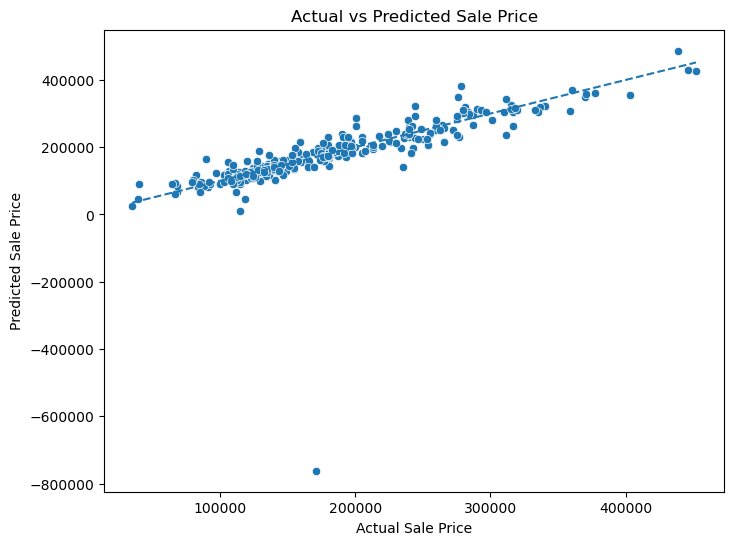

In [178]:
plt.figure(figsize=(8,6))

sns.scatterplot(x=y_test, y=y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted Sale Price")

plt.show()


## Log Transformation of Target Variable

In [181]:
y_log = np.log1p(y)

In [182]:
y_log.head()

0    12.247699
1    12.109016
2    12.317171
3    11.849405
4    12.429220
Name: SalePrice, dtype: float64

In [183]:
y_train_log = y_log.loc[X_train.index]
y_test_log = y_log.loc[X_test.index]

In [184]:
from sklearn.linear_model import LinearRegression

model_log = LinearRegression()

model_log.fit(
    X_train_final,
    y_train_log
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [185]:
y_pred_log = model_log.predict(X_test_final)

In [186]:
y_pred_log_original = np.expm1(y_pred_log)

In [188]:
mae_log = mean_absolute_error(y_test, y_pred_log_original)
mae_log

15488.855528533299

In [189]:
mse_log = mean_squared_error(y_test, y_pred_log_original)
mse_log

476003799.645556

In [190]:
rmse_log = np.sqrt(mse_log)
rmse_log

np.float64(21817.511307331915)

In [191]:
r2_log = r2_score(y_test, y_pred_log_original)
r2_log

0.9138256165158749

## Actual vs Predicted Sale Price — Log Transformed Model

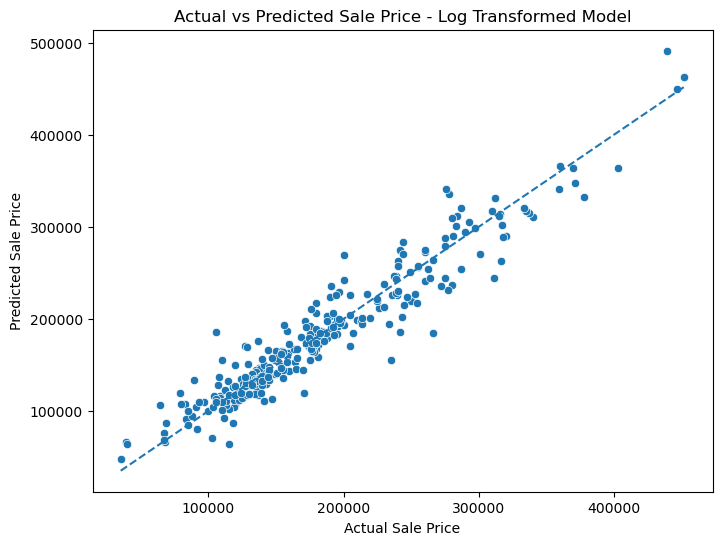

In [193]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=y_pred_log_original
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted Sale Price - Log Transformed Model")

plt.show()

#### Log transformation significantly improved the model performance.
#### The R² increased to about 0.91, while MAE and RMSE decreased.

## Ridge Regression

In [213]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=10)

In [214]:
ridge_model.fit(
    X_train_final,
    y_train_log
)

,alpha,10
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [215]:
y_pred_ridge_log = ridge_model.predict(X_test_final)

In [216]:
y_pred_ridge_original = np.expm1(y_pred_ridge_log)

In [217]:
mae_ridge = mean_absolute_error(y_test, y_pred_ridge_original)
mse_ridge = mean_squared_error(y_test, y_pred_ridge_original)
rmse_ridge = np.sqrt(mse_ridge)
mae_ridge, mse_ridge, rmse_ridge,

(14536.632647914515, 402363818.4297709, np.float64(20059.00841093026))

In [218]:
r2_ridge = r2_score(y_test, y_pred_ridge_original)
r2_ridge 

0.9271571907297324

## Final Model Evaluation

In [219]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Linear Regression + Log Transform",
        "Ridge Regression + Log Transform"
    ],
    "MAE": [
        20845.66,
        15488.86,
        14536.63
    ],
    "RMSE": [
        60111.59,
        21817.51,
        20059.01
    ],
    "R2": [
        0.3458,
        0.9138,
        0.9272
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,20845.66,60111.59,0.3458
1,Linear Regression + Log Transform,15488.86,21817.51,0.9138
2,Ridge Regression + Log Transform,14536.63,20059.01,0.9272


## Final Model: Actual vs Predicted Sale Price

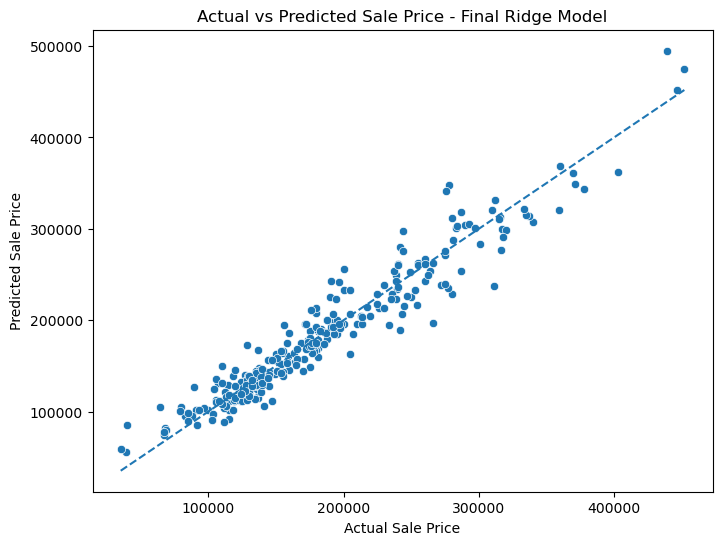

In [220]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=y_pred_ridge_original
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted Sale Price - Final Ridge Model")

plt.show()

 # Conclusion


### The House Prices dataset was analyzed through EDA, data cleaning,
### missing value handling, outlier treatment, feature engineering,
### categorical encoding, and numerical scaling.

### Several Linear Models were evaluated.
### Applying a log transformation to SalePrice significantly improved
### the prediction performance.

### The final Ridge Regression model with the log-transformed target
### achieved an R² score of approximately 0.927,
### with an MAE of approximately 14,537 and an RMSE of approximately 20,059.

### These results show that the final model can explain a large portion
### of the variation in house prices on the test set.